# DNA sequence analizi

## Problem
PhiX genomunun kompozisiyası necədir?

## Theory
GC fraction yalnız A/C/G/T bazaları üzərində hesablanır; IUPAC ambiguity ayrıca sayılır.

## Data
NC_001422.1 real genom; endirmə yoxdursa toy fallback açıq göstərilir.

Əvvəl `python scripts/fetch_data.py --dataset all` və paket quraşdırılması tamamlanmalıdır.

## Method
FASTA validation → composition → transcription/reverse complement → report

## Code

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Open notebook within the bioinformatics-lab repository")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
from run_projects import RUNNERS
run_dir = RUNNERS["dna"]()
summary = json.loads((run_dir / "summary.json").read_text())
# Summarize long sequence strings in notebook output; full result is on disk.
if "records" in summary:
    displayed = {k: {"length":v["length"], "gc_fraction":v["gc_fraction_acgt_only"], "ambiguous":v["ambiguous_bases"]} for k,v in summary["records"].items()}
else:
    displayed = summary
display(displayed)


{'NC_001422.1': {'length': 5386,
  'gc_fraction': 0.44764203490531007,
  'ambiguous': 0}}

## Result
Yuxarıdakı output faktiki bu notebook icrasının nəticəsidir. Aşağıda run-da yaranan qrafiklər göstərilir.

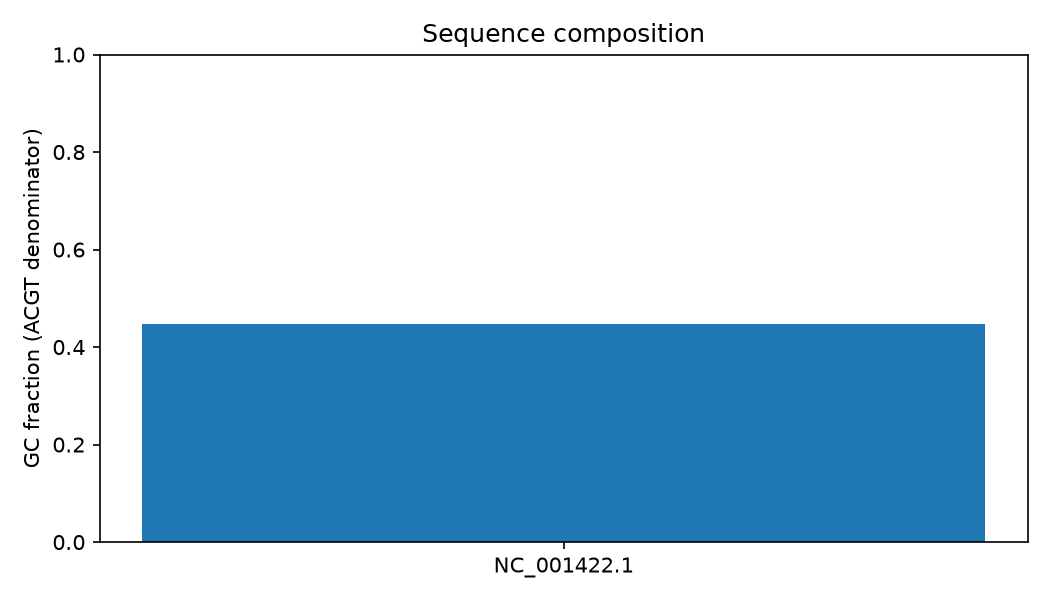

In [2]:
from IPython.display import Image, display
for figure in sorted(run_dir.glob("*.png")):
    display(Image(filename=str(figure)))

## Interpretation
GC dəyəri genomun xassəsini xülasə edir; function və ya pathogenicity barədə nəticə çıxarmır.

## Conclusion
Frame-0 codon counts tam genomda bioloji CDS translation kimi şərh edilmir.